In [1248]:
import numpy as np
import pandas as pd
import io

In [1249]:
from google.colab import files
uploaded = files.upload()

Saving house_prices.csv to house_prices (1).csv


In [1250]:
df = pd.read_csv(io.BytesIO(uploaded['house_prices (1).csv']))

In [1251]:
df.shape

(187531, 21)

In [1252]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [1253]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [1254]:
((df.isnull().sum())/df.shape[0])*100

,0
Index,0.000000
Title,0.000000
Description,1.612000
Amount(in rupees),0.000000
Price (in rupees),9.419776
location,0.000000
Carpet Area,43.018488
Status,0.327946
Floor,3.773776
Transaction,0.044259


In [1255]:
df = df.drop(columns = ['Index','Title','Description','overlooking','Society','Car Parking'])
df.head()

,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,Bathroom,Balcony,Ownership,Super Area,Dimensions,Plot Area
0,42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,1,2,NaN,NaN,NaN,NaN
1,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,2,NaN,Freehold,NaN,NaN,NaN
2,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,2,NaN,Freehold,NaN,NaN,NaN
3,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,1,1,NaN,NaN,NaN,NaN
4,1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,2,NaN,Co-operative Society,NaN,NaN,NaN


In [1256]:
df['Status'].nunique()

1

In [1257]:
df = df.drop(columns = ['Status','Plot Area','Dimensions'])
df.head()

,Amount(in rupees),Price (in rupees),location,Carpet Area,Floor,Transaction,Furnishing,facing,Bathroom,Balcony,Ownership,Super Area
0,42 Lac,6000.0,thane,500 sqft,10 out of 11,Resale,Unfurnished,NaN,1,2,NaN,NaN
1,98 Lac,13799.0,thane,473 sqft,3 out of 22,Resale,Semi-Furnished,East,2,NaN,Freehold,NaN
2,1.40 Cr,17500.0,thane,779 sqft,10 out of 29,Resale,Unfurnished,East,2,NaN,Freehold,NaN
3,25 Lac,NaN,thane,530 sqft,1 out of 3,Resale,Unfurnished,NaN,1,1,NaN,NaN
4,1.60 Cr,18824.0,thane,635 sqft,20 out of 42,Resale,Unfurnished,West,2,NaN,Co-operative Society,NaN


In [1258]:
df.shape

(187531, 12)

In [1259]:
#Identify categorical columns
df['location'].nunique()

81

In [1260]:
df['Floor'].nunique()

947

In [1261]:
df['Transaction'].nunique()

4

In [1262]:
df['Transaction'].value_counts()

,count
Transaction,
Resale,144172
New Property,42565
Other,709
Rent/Lease,2


In [1263]:
df['Furnishing'].nunique()

3

In [1264]:
df['Furnishing'].value_counts()

,count
Furnishing,
Semi-Furnished,88318
Unfurnished,76154
Furnished,20162


In [1265]:
df['facing'].nunique()

8

In [1266]:
df['facing'].value_counts()

,count
facing,
East,54741
North - East,24220
North,16533
West,8574
South,4694
North - West,3843
South - East,2622
South -West,2071


In [1267]:
df['Ownership'].nunique()

4

In [1268]:
df['Ownership'].value_counts()

,count
Ownership,
Freehold,112229
Leasehold,5285
Co-operative Society,3431
Power Of Attorney,1069


In [1269]:
#Transform amount column to values in float type data
def convert_num(x):
  if isinstance(x,str) == True:
    if 'Lac' in x:
      x = float(x.replace('Lac',""))*1e5
    elif 'Cr' in x:
      x = float(x.replace('Cr',""))*1e7
  return x

In [1270]:
df['Amount(in rupees)'] = df['Amount(in rupees)'].apply(convert_num)

In [1271]:
df.head()

,Amount(in rupees),Price (in rupees),location,Carpet Area,Floor,Transaction,Furnishing,facing,Bathroom,Balcony,Ownership,Super Area
0,4200000.0,6000.0,thane,500 sqft,10 out of 11,Resale,Unfurnished,NaN,1,2,NaN,NaN
1,9800000.0,13799.0,thane,473 sqft,3 out of 22,Resale,Semi-Furnished,East,2,NaN,Freehold,NaN
2,14000000.0,17500.0,thane,779 sqft,10 out of 29,Resale,Unfurnished,East,2,NaN,Freehold,NaN
3,2500000.0,NaN,thane,530 sqft,1 out of 3,Resale,Unfurnished,NaN,1,1,NaN,NaN
4,16000000.0,18824.0,thane,635 sqft,20 out of 42,Resale,Unfurnished,West,2,NaN,Co-operative Society,NaN


In [1272]:
df['floor number'] = df['Floor'].str.extract(r'(\d+)')
df['total floors'] = df['Floor'].str.extract(r'out of (\d+)')

In [1273]:
df['floor number'] = df['floor number'].astype(float)
df['total floors'] = df['total floors'].astype(float)
df = df.drop(columns = 'Floor')

In [1274]:
df.head()

,Amount(in rupees),Price (in rupees),location,Carpet Area,Transaction,Furnishing,facing,Bathroom,Balcony,Ownership,Super Area,floor number,total floors
0,4200000.0,6000.0,thane,500 sqft,Resale,Unfurnished,NaN,1,2,NaN,NaN,10.0,11.0
1,9800000.0,13799.0,thane,473 sqft,Resale,Semi-Furnished,East,2,NaN,Freehold,NaN,3.0,22.0
2,14000000.0,17500.0,thane,779 sqft,Resale,Unfurnished,East,2,NaN,Freehold,NaN,10.0,29.0
3,2500000.0,NaN,thane,530 sqft,Resale,Unfurnished,NaN,1,1,NaN,NaN,1.0,3.0
4,16000000.0,18824.0,thane,635 sqft,Resale,Unfurnished,West,2,NaN,Co-operative Society,NaN,20.0,42.0


In [1275]:
df['Amount(in rupees)'] = pd.to_numeric(df['Amount(in rupees)'],errors = 'coerce')

In [1276]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Amount(in rupees)  177847 non-null  float64
 1   Price (in rupees)  169866 non-null  float64
 2   location           187531 non-null  object 
 3   Carpet Area        106858 non-null  object 
 4   Transaction        187448 non-null  object 
 5   Furnishing         184634 non-null  object 
 6   facing             117298 non-null  object 
 7   Bathroom           186703 non-null  object 
 8   Balcony            138596 non-null  object 
 9   Ownership          122014 non-null  object 
 10  Super Area         79846 non-null   object 
 11  floor number       180449 non-null  float64
 12  total floors       180405 non-null  float64
dtypes: float64(4), object(9)
memory usage: 18.6+ MB


In [1277]:
#Convert Bathroom and Balcony features to numeric
df['Bathroom'] = pd.to_numeric(df['Bathroom'],errors = 'coerce')
df['Balcony'] = pd.to_numeric(df['Balcony'], errors = 'coerce')

In [1278]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Amount(in rupees)  177847 non-null  float64
 1   Price (in rupees)  169866 non-null  float64
 2   location           187531 non-null  object 
 3   Carpet Area        106858 non-null  object 
 4   Transaction        187448 non-null  object 
 5   Furnishing         184634 non-null  object 
 6   facing             117298 non-null  object 
 7   Bathroom           186668 non-null  float64
 8   Balcony            138574 non-null  float64
 9   Ownership          122014 non-null  object 
 10  Super Area         79846 non-null   object 
 11  floor number       180449 non-null  float64
 12  total floors       180405 non-null  float64
dtypes: float64(6), object(7)
memory usage: 18.6+ MB


In [1279]:
y = df['Price (in rupees)']
x = df.drop(columns = 'Price (in rupees)')

In [1280]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [1281]:
#treat missing values in float types
x = ['Amount(in rupees)','Bathroom','Balcony','floor number','total floors']
for i in x:
  x_train[i] = x_train[i].fillna(x_train[i].mean())
for i in x:
  x_test[i] = x_test[i].fillna(x_test[i].mean())


In [1282]:
#Carpet Area(High Missing)
x_train['Carpet Area'] = x_train['Carpet Area'].str.extract(r'(\d+)').astype(float)
x_train['Carpet Area Missing'] = x_train['Carpet Area'].isna().astype(int)
x_test['Carpet Area'] = x_test['Carpet Area'].str.extract(r'(\d+)').astype(float)
x_test['Carpet Area Missing'] = x_test['Carpet Area'].isna().astype(int)


In [1283]:
x_train['Carpet Area'] = x_train['Carpet Area'].fillna(x_train['Carpet Area'].median())
x_test['Carpet Area'] = x_test['Carpet Area'].fillna(x_test['Carpet Area'].median())


In [1284]:
#Super Area(High Missing)
x_train['Super Area'] = x_train['Super Area'].str.extract(r'(\d+)').astype(float)
x_train['Super Area Missing'] = x_train['Super Area'].isna().astype(int)
x_test['Super Area'] = x_test['Super Area'].str.extract(r'(\d+)').astype(float)
x_test['Super Area Missing'] = x_test['Super Area'].isna().astype(int)

In [1285]:
x_train['Super Area'] = x_train['Super Area'].fillna(x_train['Super Area'].median())
x_test['Super Area'] = x_test['Super Area'].fillna(x_test['Super Area'].median())


In [1286]:
y_train = y_train.fillna(y_train.mean())
y_test = y_test.fillna(y_test.mean())

In [1287]:
#fill non numeric missing values
x = ['location', 'Transaction', 'Furnishing', 'facing', 'Ownership']
x_replace = ['Unknown location','Unknown Transaction','Unknown Furnishing' ,'Unknown facing', 'Unknown Ownership']
j = 0

for i in x:
  x_train[i] = x_train[i].replace(np.nan,x_replace[j])
  j = j+1

In [1288]:
x = ['location', 'Transaction', 'Furnishing', 'facing', 'Ownership']
x_replace = ['Unknown location','Unknown Transaction','Unknown Furnishing' ,'Unknown facing', 'Unknown Ownership']
j = 0

for i in x:
  x_test[i] = x_test[i].replace(np.nan,x_replace[j])
  j = j+1

In [1289]:
#Target encoding for location feature
train_data = x_train.copy()
train_data['Price'] = y_train.copy()
train_data.head()

,Amount(in rupees),location,Carpet Area,Transaction,Furnishing,facing,Bathroom,Balcony,Ownership,Super Area,floor number,total floors,Carpet Area Missing,Super Area Missing,Price
151915,7590000.0,chandigarh,1390.0,New Property,Semi-Furnished,North - East,3.0,4.0,Freehold,1250.0,4.0,4.0,0,1,3941.0
143399,5870000.0,noida,600.0,Resale,Furnished,East,1.0,2.0,Leasehold,1250.0,9.0,14.0,0,1,9785.0
96671,26000000.0,kolkata,1000.0,Resale,Unfurnished,South,3.0,1.0,Freehold,1705.0,10.0,19.0,1,0,15249.0
148543,1800000.0,aurangabad,1000.0,Resale,Unfurnished,East,2.0,1.0,Co-operative Society,595.0,2.0,2.0,1,0,3025.0
56127,9000000.0,gurgaon,1140.0,Resale,Semi-Furnished,East,2.0,4.0,Freehold,1250.0,7.0,21.0,0,1,6316.0


In [1290]:
encode_map = train_data.groupby('location')['Price'].mean()
encode_map.head()

,Price
location,
agra,16719.888897
ahmadnagar,4223.398232
ahmedabad,5552.152128
allahabad,8070.593814
aurangabad,4860.075085


In [1291]:
encode_map.shape

(81,)

In [1292]:
x_train['location'] = x_train['location'].map(encode_map)
x_test['location'] = x_test['location'].map(encode_map)
x_test['location'] = x_test['location'].fillna(x_test['location'].mean())

In [1293]:
#Hot encoding for categorical features
x_train = pd.get_dummies(x_train,columns = ['Transaction','Furnishing','facing','Ownership'])
x_test =  pd.get_dummies(x_test,columns = ['Transaction','Furnishing','facing','Ownership'])
x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)


In [1294]:
bool_cols = x_train.select_dtypes(include = 'bool').columns
x_train[bool_cols] = x_train[bool_cols].astype(int)

In [1295]:
bool_cols_test = x_test.select_dtypes(include = 'bool').columns
x_test[bool_cols_test] = x_test[bool_cols_test].astype(int)

In [1296]:
x_train.shape

(150024, 33)

In [1297]:
x_test.shape

(37507, 33)

In [1298]:
y_test.shape

(37507,)

In [1299]:
y_train.shape

(150024,)

In [1300]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state = 42)
rf.fit(x_train, y_train)
print(rf.score(x_test, y_test))

0.8037324886603239


In [1301]:
print(rf.score(x_train, y_train))
print(rf.score(x_test, y_test))

0.9194230020881675
0.8037324886603239


In [1302]:
y_pred = rf.predict(x_test)

In [1303]:
from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

MAE = mean_absolute_error(y_test,y_pred)
RMSE = sqrt(mean_squared_error(y_test,y_pred))
R2 = r2_score(y_test,y_pred)

print(MAE)
print(RMSE)
print(R2)


563.3453295654542
9454.050708481225
0.8037324886603239


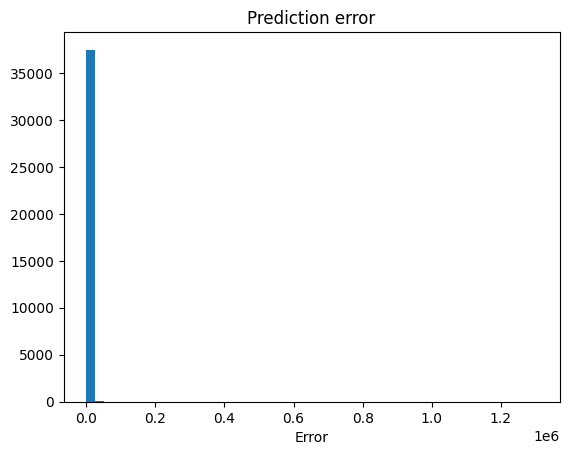

In [1304]:
import matplotlib.pyplot as plt
errors = abs(y_test - y_pred)
plt.title("Prediction error")
plt.xlabel("Error")
plt.hist(errors,bins = 50)
#plt.xlim(0,3e4)
plt.show()

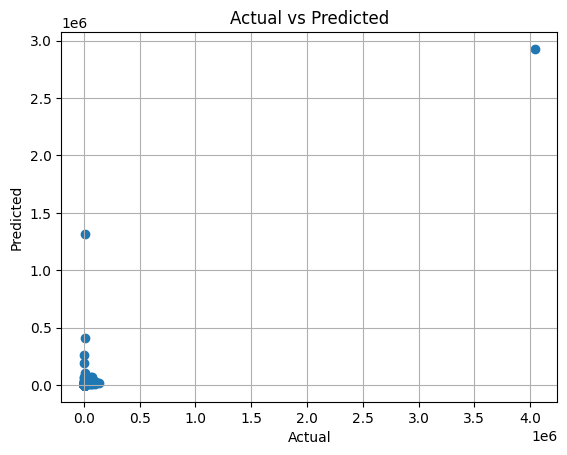

In [1317]:
plt.scatter(y_test,y_pred)
plt.title("Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid()
#plt.xlim(0,2e5)
#plt.ylim(0,5e5)
#Uncomment these lines to visualize that the relationship is linear for most of the data
plt.show()

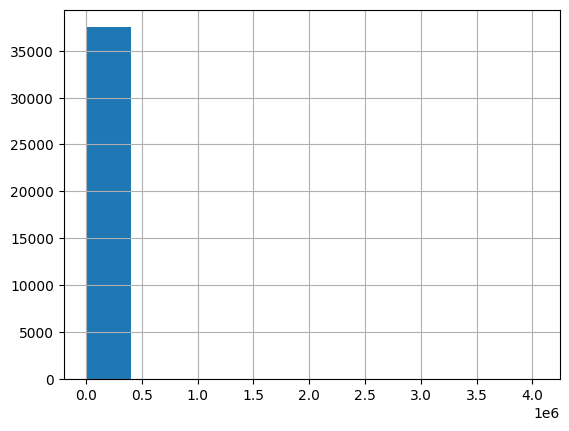

In [1306]:
plt.hist(y_test)
#plt.xlim(0,1e6)
plt.grid()
plt.show()

In [1307]:
y_test.mean()

np.float64(7533.374381188119)

In [1308]:
y_pred.mean()

np.float64(7699.787667300181)

In [1309]:
y_test.min()

0.0

In [1310]:
y_pred.min()

np.float64(425.66)

In [1311]:
#save the model,location_list and encode_map
import pickle
pickle.dump(rf,open("model.pkl","wb"))

In [1312]:
location_list = df['location'].unique()
pickle.dump(location_list,open("location_list.pkl","wb"))

In [1313]:
pickle.dump(encode_map,open("encode_map.pkl","wb"))

In [1314]:
%%writefile RentPredict.py
import streamlit as st
import pickle
import numpy as np

model = pickle.load(open("model.pkl","rb"))
location_list = pickle.load(open("location_list.pkl","rb"))
encode_map = pickle.load(open("encode_map.pkl","rb"))

st.title("House Rent Prediction")
st.text("This app predicts the rent of house in indian cities. Fill the information to predict your rent.")

Amount = st.number_input("Enter house price(INR): ",100000.0,15000000000.0)

location = st.selectbox("Select location",location_list)
location_num = encode_map[location]


carpet_area = st.number_input("Carpet Area(in sqft): ",1.0,800000.0)
bathroom = st.slider("No. of Washrooms: ",1,10)
balcony = st.slider("No. of Balconies: ",1,10)
super_area = st.slider("Super Area(in sqft): ",1.0,10000.0)
floor_number = st.slider("Floor Number : ",1,200)
total_floors = st.slider("Total no. of floors: ",floor_number,200)

carpet_area_missing = 0
super_area_missing = 0

#Transaction
Transaction_list = ['New Property','Rent/Lease', 'Resale','Other','Unknown']
Transaction = st.selectbox("Select transaction type: ",Transaction_list)
Transaction_features = np.zeros(5)

for i in range(0,len(Transaction_list)):
  if Transaction == Transaction_list[i]:
    Transaction_features[i] = 1
    break

Transaction_New_Property = Transaction_features[0]
Transaction_Rent_Lease = Transaction_features[1]
Transaction_Resale = Transaction_features[2]
Transaction_Other = Transaction_features[3]
Transaction_Unknown = Transaction_features[4]

Transaction_features = np.zeros(5)

#Furnishing
Furnishing_list = ['Furnished','Semi Furnished','Unfurnished','Unknown']
Furnishing = st.selectbox("Select Furnishing: ",Furnishing_list)
Furnishing_features = np.zeros(4)

for i in range(0,len(Furnishing_list)):
  if Furnishing == Furnishing_list[i]:
    Furnishing_features[i] = 1
    break

Furnishing_Furnished = Furnishing_features[0]
Furnishing_Semi_Furnished = Furnishing_features[1]
Furnishing_Unfurnished = Furnishing_features[2]
Furnishing_Unknown = Furnishing_features[3]

Furnishing_features = np.zeros(4)

#facing
facing_list = ['East','West','North','South','North East','North West','South East','South West','Unknown']
facing = st.selectbox("Facing direction: ",facing_list)
facing_features = np.zeros(9)

for i in range(0,len(facing_list)):
  if facing == facing_list[i]:
    facing_features[i] = 1
    break

facing_East = facing_features[0]
facing_West = facing_features[1]
facing_North = facing_features[2]
facing_South = facing_features[3]
facing_North_East = facing_features[4]
facing_North_West = facing_features[5]
facing_South_East = facing_features[6]
facing_South_West = facing_features[7]
facing_Unknown = facing_features[8]

facing_features = np.zeros(9)

#Ownership
Ownership_list = ['Cooperative Society','Freehold','Leasehold','Power of Attorney','Unknown']
Ownership = st.selectbox("Select Ownership type: ",Ownership_list)
Ownership_features = np.zeros(5)

for i in range(0,len(Ownership_list)):
  if Ownership == Ownership_list[i]:
    Ownership_features[i] = 1
    break

Owner_cooperative = Ownership_features[0]
Owner_freehold = Ownership_features[1]
Owner_leasehold = Ownership_features[2]
Owner_power_of_attorney = Ownership_features[3]
Owner_Unknown = Ownership_features[4]

Ownership_features = np.zeros(5)

if st.button("Predict Rent"):
  y_predict = model.predict([[Amount,location_num,carpet_area,bathroom,balcony,super_area,floor_number,total_floors,carpet_area_missing,super_area_missing,
                             Transaction_New_Property,Transaction_Other,Transaction_Rent_Lease,Transaction_Resale,Transaction_Unknown,Furnishing_Furnished,
                             Furnishing_Semi_Furnished,Furnishing_Unfurnished,Furnishing_Unknown,facing_East,facing_North,facing_North_East,facing_North_West,
                             facing_South,facing_South_East,facing_South_West,facing_Unknown,facing_West,Owner_cooperative, Owner_freehold,Owner_leasehold,
                              Owner_power_of_attorney,Owner_Unknown]])
  prediction = y_predict[0]
  st.success(f"House rent: ₹ {round(prediction,2)}")




Overwriting RentPredict.py


In [1315]:
files.download('model.pkl')
files.download('location_list.pkl')
files.download('encode_map.pkl')
files.download('RentPredict.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>